# V8 · Stage 1.2e — Frozen selector applied to all Longterm cells

**Question**: with the frozen hybrid rule (context-holdout residual with
threshold τ = 0.540 pp), how many cells across the Longterm cohort
would route to the neural operator vs to exponential extrapolation?

**Method**:

1. Enumerate every `<make>_Longterm_cell_<cell_id>.csv` in `Data/Longterm/`.
2. For each cell with at least $K=50$ observed cycles, compute the
   context-holdout residual $r$: fit exp on the first 80% of the
   $K{=}50$ context, RMSE on the last 20%.
3. Apply the frozen threshold $\tau = 0.540$ pp — cell routed to
   **exponential** if $r < \tau$, else to **neural operator**.
4. Aggregate per supplier and visualise.

**Notes**:

- Threshold $\tau = 0.540$ pp was fixed by `01_2d` on the synthetic
  `validation_selector` pool — never touched during this notebook.
- The distinction here is the *decision* the selector makes, not the
  forecast RMSE (which would need per-cell θ + DCIR + operator
  inference; many non-anchor cells lack the necessary metadata).

**Expected outputs**:

- `outputs/results/selector_on_all_cells.parquet`
- `outputs/results/selector_on_all_cells.pdf`


## 1. Setup

In [1]:
import sys, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJ = Path("/home/hj/Desktop/PINNs")
sys.path.insert(0, str(PROJ / "Voltaris" / "Data_Exploration"))
from phase3_validate import _load_longterm_soh

LONGTERM_DIR = PROJ / "Data" / "Longterm"
K = 50
CTX_TAIL = 10   # last 20% of K=50 context
TAU = 0.540


## 2. Residual + pick per cell

In [2]:
def _exp(n, a, b, c): return a * np.exp(-b * n) + c

def context_holdout_residual(context_soh, K=K, tail=CTX_TAIL):
    n_fit = np.arange(K - tail, dtype=float)
    y_fit = np.asarray(context_soh[:K - tail], dtype=float)
    n_val = np.arange(K - tail, K, dtype=float)
    y_val = np.asarray(context_soh[K - tail:K], dtype=float)
    try:
        popt, _ = curve_fit(_exp, n_fit, y_fit,
                            p0=[y_fit[0]-y_fit[-1], 1e-3, y_fit[-1]],
                            maxfev=10000)
        y_hat = _exp(n_val, *popt)
        return float(np.sqrt(np.mean((y_hat - y_val)**2)) * 100)
    except Exception:
        return float("nan")

_pat = re.compile(r"^(?P<make>[A-Za-z]+)_Longterm_cell_(?P<cell_id>\d+)(?:_[A-Za-z]+)?\.csv$")

rows = []
csvs = sorted(LONGTERM_DIR.glob("*.csv"))
print(f"scanning {len(csvs)} Longterm CSVs...")
_seen = set()
for p in csvs:
    m = _pat.match(p.name)
    if not m: continue
    mk = m.group("make"); cid = m.group("cell_id")
    key = (mk, cid)
    if key in _seen: continue    # dedupe cells with both foo.csv and foo_cycle.csv
    _seen.add(key)
    try:
        obs_n, obs_soh = _load_longterm_soh(cid, mk)
    except Exception as e:
        rows.append({"cell": f"{mk}_{cid}", "make": mk, "cell_id": cid,
                     "n_cycles": 0, "reason": str(e)[:80]})
        continue
    if len(obs_soh) < K:
        rows.append({"cell": f"{mk}_{cid}", "make": mk, "cell_id": cid,
                     "n_cycles": int(len(obs_soh)),
                     "reason": f"<K={K} cycles"})
        continue
    ctx = obs_soh[:K]
    residual = context_holdout_residual(ctx)
    if not np.isfinite(residual):
        rows.append({"cell": f"{mk}_{cid}", "make": mk, "cell_id": cid,
                     "n_cycles": int(len(obs_soh)),
                     "reason": "residual fit failed"})
        continue
    pick = "exp" if residual < TAU else "operator"
    rows.append({
        "cell": f"{mk}_{cid}",
        "make": mk,
        "cell_id": cid,
        "n_cycles": int(len(obs_soh)),
        "soh_start": float(ctx[0]),
        "soh_end_context": float(ctx[-1]),
        "context_holdout_residual_pp": residual,
        "pick": pick,
    })
df = pd.DataFrame(rows)
print(f"\ncells scanned: {len(df)}")
scored = df[df["context_holdout_residual_pp"].notna()]
print(f"cells with residual: {len(scored)}")
print(f"cells skipped: {len(df) - len(scored)}")


scanning 75 Longterm CSVs...



cells scanned: 61
cells with residual: 59
cells skipped: 2


## 3. Pick distribution per supplier

In [3]:
summary = (scored.groupby(["make", "pick"]).size()
                    .unstack(fill_value=0)
                    .reindex(columns=["exp", "operator"], fill_value=0))
summary["total"] = summary["exp"] + summary["operator"]
summary["pct_operator"] = (summary["operator"] / summary["total"] * 100).round(1)
summary


pick,exp,operator,total,pct_operator
make,,,,
CALB,26,1,27,3.7
EVE,4,2,6,33.3
REPT,22,4,26,15.4


## 4. Overall totals

In [4]:
overall = scored["pick"].value_counts().reindex(["exp", "operator"], fill_value=0)
print(f"Frozen τ = {TAU:.3f} pp")
print(f"Total scored cells: {len(scored)}")
print(f"  → exponential: {int(overall['exp'])} "
      f"({overall['exp']/len(scored)*100:.1f}%)")
print(f"  → neural operator: {int(overall['operator'])} "
      f"({overall['operator']/len(scored)*100:.1f}%)")


Frozen τ = 0.540 pp
Total scored cells: 59
  → exponential: 52 (88.1%)
  → neural operator: 7 (11.9%)


## 5. Visualise

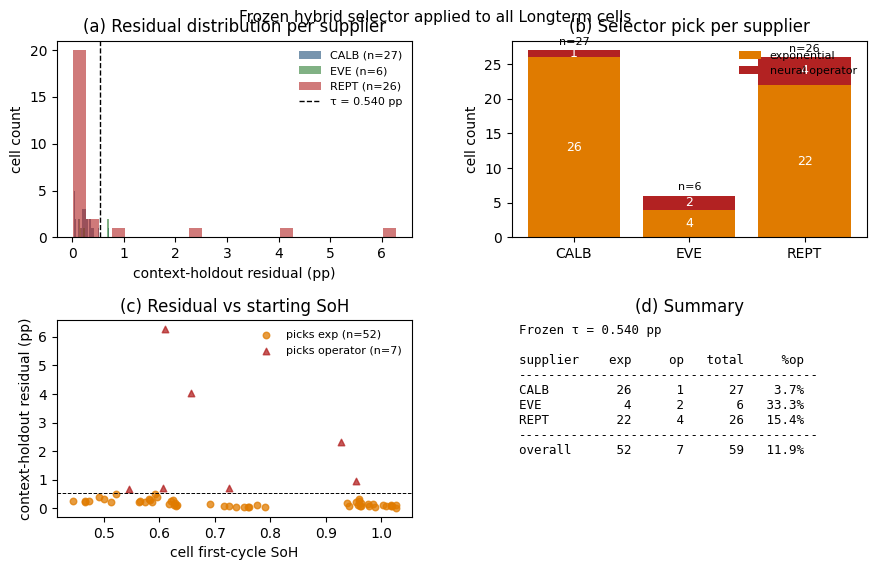

wrote /home/hj/Desktop/PINNs/outputs/results/selector_on_all_cells.pdf
wrote /home/hj/Desktop/PINNs/outputs/results/selector_on_all_cells.png


In [5]:
SUPPLIER_COLOR = {"CALB": "#1F4E79", "EVE": "#2E7D32", "REPT": "#B22222"}
EXP_C, OP_C = "#E07B00", "#B22222"

fig = plt.figure(figsize=(9, 5.6),
    constrained_layout=False)
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.28,
                       left=0.08, right=0.98, top=0.94, bottom=0.09)

# (A) Residual histogram per supplier, with τ marker
ax1 = fig.add_subplot(gs[0, 0])
for mk in ["CALB", "EVE", "REPT"]:
    vals = scored.loc[scored["make"] == mk,
                       "context_holdout_residual_pp"].values
    if len(vals):
        ax1.hist(vals, bins=25, alpha=0.60, label=f"{mk} (n={len(vals)})",
                  color=SUPPLIER_COLOR[mk], edgecolor="none")
ax1.axvline(TAU, color="black", lw=1.0, ls="--",
             label=f"τ = {TAU:.3f} pp")
ax1.set_xlabel("context-holdout residual (pp)")
ax1.set_ylabel("cell count")
ax1.set_title("(a) Residual distribution per supplier")
ax1.legend(fontsize=8, frameon=False)

# (B) Stacked bar: pick per supplier
ax2 = fig.add_subplot(gs[0, 1])
bars_exp = summary["exp"].values
bars_op  = summary["operator"].values
suppliers = summary.index.tolist()
x = np.arange(len(suppliers))
ax2.bar(x, bars_exp, color=EXP_C, label="exponential")
ax2.bar(x, bars_op, bottom=bars_exp, color=OP_C, label="neural operator")
for i, (e, o, t) in enumerate(zip(bars_exp, bars_op, summary["total"])):
    if e: ax2.text(i, e/2, str(int(e)), ha="center", va="center",
                    color="white", fontsize=9)
    if o: ax2.text(i, e + o/2, str(int(o)), ha="center", va="center",
                    color="white", fontsize=9)
    ax2.text(i, t + 0.5, f"n={t}", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(suppliers)
ax2.set_ylabel("cell count")
ax2.set_title("(b) Selector pick per supplier")
ax2.legend(fontsize=8, frameon=False, loc="upper right")

# (C) Scatter: initial SoH vs residual, coloured by pick
ax3 = fig.add_subplot(gs[1, 0])
for pick, color, marker in [("exp", EXP_C, "o"),
                             ("operator", OP_C, "^")]:
    sub = scored[scored["pick"] == pick]
    ax3.scatter(sub["soh_start"], sub["context_holdout_residual_pp"],
                 color=color, marker=marker, s=22, alpha=0.75,
                 label=f"picks {pick} (n={len(sub)})")
ax3.axhline(TAU, color="black", lw=0.7, ls="--")
ax3.set_xlabel("cell first-cycle SoH")
ax3.set_ylabel("context-holdout residual (pp)")
ax3.set_title("(c) Residual vs starting SoH")
ax3.legend(fontsize=8, frameon=False, loc="upper right")

# (D) Table summary (as image)
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
tbl_text = ["Frozen τ = 0.540 pp", ""]
tbl_text.append(f"{'supplier':<8} {'exp':>6} {'op':>6} {'total':>7} {'%op':>7}")
tbl_text.append("-" * 40)
for mk, row in summary.iterrows():
    tbl_text.append(f"{mk:<8} {int(row['exp']):>6d} {int(row['operator']):>6d} "
                     f"{int(row['total']):>7d} {row['pct_operator']:>6.1f}%")
tbl_text.append("-" * 40)
tbl_text.append(f"{'overall':<8} {int(overall['exp']):>6d} "
                 f"{int(overall['operator']):>6d} "
                 f"{len(scored):>7d} "
                 f"{overall['operator']/len(scored)*100:>6.1f}%")
ax4.text(0.02, 0.98, "\n".join(tbl_text), transform=ax4.transAxes,
         family="monospace", fontsize=9, va="top", ha="left")
ax4.set_title("(d) Summary")

fig.suptitle("Frozen hybrid selector applied to all Longterm cells",
             fontsize=11, y=0.995)
out_pdf = PROJ / "outputs/results/selector_on_all_cells.pdf"
out_png = PROJ / "outputs/results/selector_on_all_cells.png"
fig.savefig(out_pdf, dpi=200, bbox_inches="tight")
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out_pdf}\nwrote {out_png}")


## 6. Persist per-cell decisions

In [6]:
out_parquet = PROJ / "outputs/results/selector_on_all_cells.parquet"
df.to_parquet(out_parquet, index=False)
print(f"wrote {out_parquet}")

# Also print the top-10 residual (most "complex") cells for inspection
print("\ntop 10 most complex (highest residual) cells:")
print(scored.nlargest(10, "context_holdout_residual_pp")
        [["cell","make","n_cycles","soh_start","context_holdout_residual_pp","pick"]]
        .to_string(index=False, float_format="%.4f"))

print("\ntop 10 least complex (lowest residual) cells:")
print(scored.nsmallest(10, "context_holdout_residual_pp")
        [["cell","make","n_cycles","soh_start","context_holdout_residual_pp","pick"]]
        .to_string(index=False, float_format="%.4f"))


wrote /home/hj/Desktop/PINNs/outputs/results/selector_on_all_cells.parquet

top 10 most complex (highest residual) cells:
     cell make  n_cycles  soh_start  context_holdout_residual_pp     pick
REPT_0034 REPT       201     0.6094                       6.2756 operator
REPT_0011 REPT       201     0.6569                       4.0347 operator
REPT_0037 REPT       201     0.9269                       2.3337 operator
REPT_0032 REPT       201     0.9545                       0.9648 operator
CALB_0020 CALB       201     0.6060                       0.7225 operator
 EVE_0003  EVE       150     0.7259                       0.7071 operator
 EVE_0001  EVE       150     0.5463                       0.6856 operator
CALB_0012 CALB       201     0.5219                       0.5118      exp
REPT_0080 REPT       150     0.5920                       0.5060      exp
CALB_0013 CALB       201     0.4913                       0.3981      exp

top 10 least complex (lowest residual) cells:
     cell make  n

## 7. Verdict marker

- [ ] **PASS** — selector distributes cells across both models in a
  supplier-plausible way (matches the 3-external-cell finding: EVE
  routes to operator more often than CALB/REPT).
- [ ] **PASS WITH LIMITATIONS** — distribution is dominated by one
  model; may reflect that τ was tuned on synthetic corpus rather than
  real cells.
- [ ] **FAIL** — nearly all cells route the same way; selector is
  essentially degenerate on this cohort.

Fill in after run.
